First of all, set the 'CODE_DIR' to where the model code are saved. This will change current working directory and print for checking. Afterwards, we import all required modules.

In [1]:
import os

# Save the current PATH
original_path = os.environ['PATH']

# Set CUDA 12.5 environment variables, appending the original PATH explicitly
os.environ['CUDA_HOME'] = '/usr/local/cuda-12.5'
os.environ['PATH'] = f"/usr/local/cuda-12.5/bin:{original_path}"
os.environ['LD_LIBRARY_PATH'] = f"/usr/local/cuda-12.5/lib64:{os.environ.get('LD_LIBRARY_PATH', '')}"

#!rm -rf /home/ids/yuhe/.cache/torch_extensions


In [2]:
CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_CS-StyleGAN'

import os
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()
print('Current working directory is:', '\n', notebook_path) 

from argparse import Namespace
import time
import sys
import pprint
import numpy as np
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.append(".")
sys.path.append("..")

# from datasets import augmentations
from utils.common import tensor2im, log_input_image
# from models.psp import pSp

from notebooks.def_funcs import load_c_s1_s2_model, load_ema_model, evaluate_model, transform_images_to_batch, load_folder_images, \
    show_latent_map, visulize_singleImg_paired2, visulize_singleImg_paired3, visulize_singleImg_paired4, visulize_singleImg_paired5, evaluate_learn_scaled_st, evaluate_scaled_st
# %load_ext autoreload
# %autoreload 2

Current working directory is: 
 /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_CS-StyleGAN


## Parameters setting

Fell free to change the golobal parameters for all experiments

In [14]:
EXPERIMENT_PARMS = {
        "model_path": "./results/c_sep_s1s2/afhqv2/lr_1e-3/checkpoints/iteration_80000.pt",
        "images_bg_path" : "/home/ids/yuhe/Projects/CA_with_GAN/2_data/styleGAN/AFHQ/afhq-v2/test/cat", 
        "images_t_path" : "/home/ids/yuhe/Projects/CA_with_GAN/2_data/styleGAN/AFHQ/afhq-v2/test/dog", 
        "model_output_size" : 512,
        "transform": transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])]) 
}

### Set parameters

In [10]:
model_path = EXPERIMENT_PARMS['model_path']
#model_weight3_path = EXPERIMENT_PARMS['model_weight3_path']

image_bg_paths = EXPERIMENT_PARMS["images_bg_path"]
image_t_paths = EXPERIMENT_PARMS["images_t_path"]

transform = EXPERIMENT_PARMS['transform']
device = 'cuda'

### Load pretrained pSp model

In [11]:
def get_results(pSp_net, cs_mlp_net, input_images_bg, input_images_t):
    _, w_bg_pSp = pSp_net.forward(input_images_bg, return_latents=True)
    _, w_t_pSp = pSp_net.forward(input_images_t, return_latents=True) 

    latent_bg_c, latent_bg_s1, latent_bg_s2 = cs_mlp_net(w_bg_pSp)
    latent_t_c, latent_t_s1, latent_t_s2 = cs_mlp_net(w_t_pSp) 

    rec_x_bg = pSp_net.forward(latent_bg_c + latent_bg_s1, input_code=True, randomize_noise=True, recon_modle=True)
    rec_x_t = pSp_net.forward(latent_t_c + latent_t_s2, input_code=True, randomize_noise=True, recon_modle=True)	

    swap_x_bg = pSp_net.forward(latent_bg_c + latent_t_s2, input_code=True, randomize_noise=True, recon_modle=True)
    swap_x_t = pSp_net.forward(latent_t_c + latent_bg_s1, input_code=True, randomize_noise=True, recon_modle=True)	

    return rec_x_bg, rec_x_t, swap_x_bg, swap_x_t

In [15]:
pSp_net, cs_mlp_net, opts = load_c_s1_s2_model(model_path, device=device)

Loading trained checkpoint from path: ./results/c_sep_s1s2/afhqv2/lr_1e-3/checkpoints/iteration_80000.pt
training_step:  80000
Loading pSp from checkpoint: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/afhqv2/ffhq_params/checkpoints/iteration_300000.pt
Loading trained checkpoint from path: ./results/c_sep_s1s2/afhqv2/lr_1e-3/checkpoints/iteration_80000.pt


### Perform encode and decode for inversion

seed:  9599
id-0


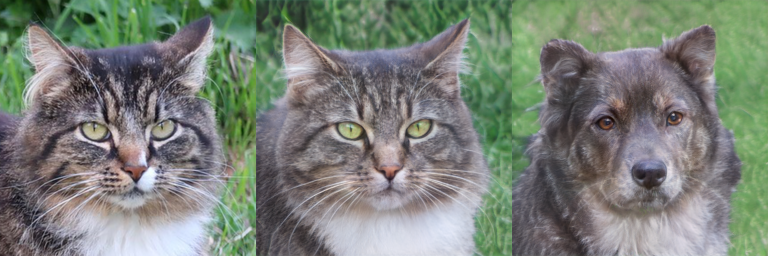

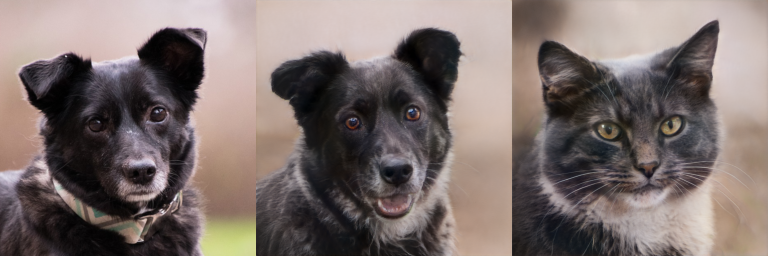

id-1


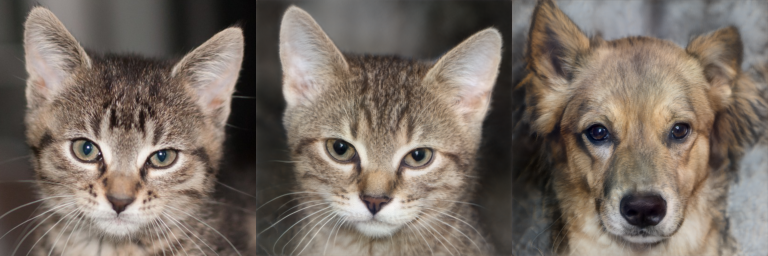

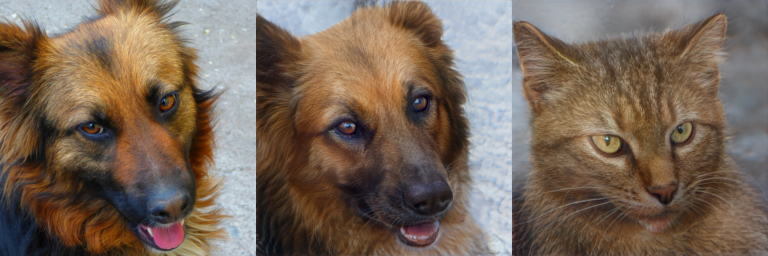

id-2


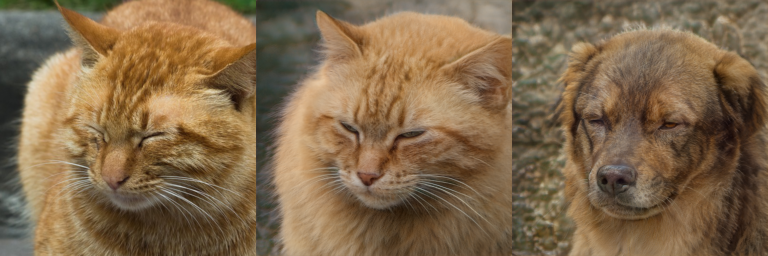

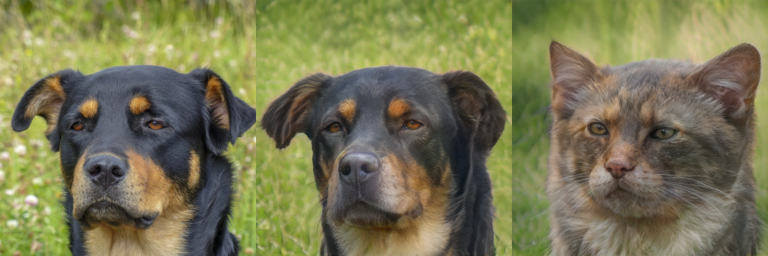

id-3


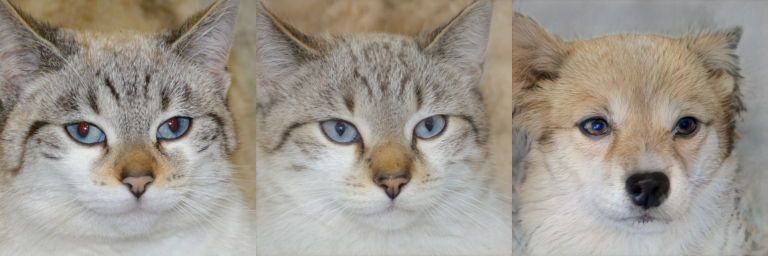

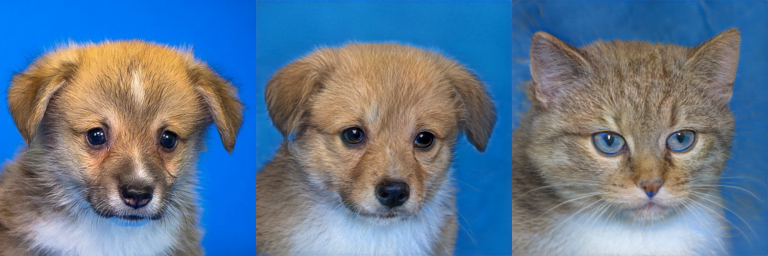

In [ ]:
# batched_input shape: bs x 3 x w x h
# avaliable seed for ages:   815  6765 7352  9936  476 4432
# Generate a random integer  
# smile seed 53  
# for dog-cat seed: 6514
with torch.no_grad():
    import random
    random_seed = random.randint(0, 10000)  # Using the range of a typical 32-bit signed integer
    print('seed: ', random_seed)  
    #random_seed = 7856
    # image_bg_paths = 'notebooks/gender/male'
    # image_t_paths = 'notebooks/gender/female'
    %matplotlib inline
    images_bg = load_folder_images(image_bg_paths, num_images=4, seed=random_seed)
    images_t= load_folder_images(image_t_paths, num_images=4, seed=random_seed)

    input_images_bg = transform_images_to_batch(images_bg, transform).to(device).float()
    input_images_t = transform_images_to_batch(images_t, transform).to(device).float()

    custom_indices = torch.tensor([3, 0, 1, 2])  # Example custom order for batch size of 4
    input_images_bg = input_images_bg[custom_indices]

    rec_x_bg, rec_x_t, swap_x_bg, swap_x_t = get_results(pSp_net, cs_mlp_net, input_images_bg, input_images_t)
    # # visulize_images_batch(recon_t, axis_dim=1)
    n_images = rec_x_bg.shape[0]

    # for i in range (n_images):
    #     visulize_singleImg_paired2(input_images_bg[i,:,:,:], output_images_1['recon_bg'][i,:,:,:])
    # for i in range (n_images):
    #     visulize_singleImg_paired2(input_images_t[i,:,:,:], output_images_1['recon_t'][i,:,:,:])

    for i in range (n_images):
        print(f'id-{i}')
        visulize_singleImg_paired3(input_images_bg[i,:,:,:], rec_x_bg[i,:,:,:], swap_x_bg[i,:,:,:])
        visulize_singleImg_paired3(input_images_t[i,:,:,:], rec_x_t[i,:,:,:],  swap_x_t[i,:,:,:])


cp /lustre/fsn1/projects/rech/hht/usv51hl/Projects/data/BraTS2023/train_healthy/*.{jpg,png} /path/to/dest/

In [9]:
# # compute output sparsity for latent_t_s
# #images_idx = 1
# show_latent_map(output_latents_1['latent_t_s'], img_idx = 0, show_weight = 50)
# show_latent_map(output_latents_2['latent_t_s'], img_idx = 0, show_weight = 50)
# show_latent_map(output_latents_3['latent_t_s'], img_idx = 0, show_weight = 50)

# calculate_output_sparsity